<a href="https://colab.research.google.com/github/AMIRMOHAMMAD-OSS/Phaseek/blob/main/phaseek_n2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phaseek: Liquid–Liquid Phase Separation (LLPS) Protein Scorer  

<img src="https://raw.githubusercontent.com/AMIRMOHAMMAD-OSS/Phaseek/main/Picture10.svg" alt="Phaseek Logo" width="800"/>  

**Phaseek** is a lightweight tool designed to evaluate protein sequences for their likelihood of undergoing liquid–liquid phase separation.  

### How to Use
- **Single sequence:** Paste a protein sequence directly into the input box.  
- **Multiple sequences:** Upload a FASTA file containing several protein sequences (recommended maximum: **100 sequences** for smooth performance).  
- **Targeted analysis:** Provide a sequence ID or directory to specify which sequence(s) to score.  
- **Custom range:** Use the `End_Sequence` parameter to restrict scoring up to a defined endpoint within the sequence.  

⚡ With Phaseek, you can rapidly explore LLPS propensities while keeping your workflow efficient and scalable.

In [1]:
#@title Installation
%%capture
!pip install biopython streamlit py3Dmol requests biotite stmol command_runner plotly "kaleido==0.1.*" transformers ipympl
!apt-get update -qq && apt-get install -y ncbi-blast+


In [2]:
#@title Setup
%%time
import os, time ,io
import torch
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from command_runner import command_runner
import torch
import numpy as np
from google.colab import output


try:
  if not os.path.isfile("/content/Phaseek/Functions/Configue.py"):
      os.makedirs('/content/Phaseek/', exist_ok=True)
      !git clone https://github.com/AMIRMOHAMMAD-OSS/Phaseek /content/Phaseek/
      %cd /content/Phaseek/Functions
      output.clear()
      print("Everything looks ok! ✨🍰✨\n\n\n\n")

  else:
      %cd /content/Phaseek/Functions
      output.clear()
      print("Phaseek already installed, ready to run!\n\n")
except:
  print("Sonthing has gone wrong!")


Everything looks ok! ✨🍰✨




CPU times: user 1.54 s, sys: 296 ms, total: 1.84 s
Wall time: 9.88 s


In [3]:
#@title Device Availability

if torch.cuda.is_available():
  print("Cuda is available 🎉\n")
  print("The allocated device is : "+torch.cuda.get_device_name())
  device = torch.device("cuda")
else:
  print("Cuda is not available 😔\n")
  print("The allocated device is : cpu")
  device = torch.device("cpu")


Cuda is available 🎉

The allocated device is : Tesla T4


In [4]:
#@title Loading sequence , then hit `Runtime` -> `Run all`
#@markdown - Load the `Sequence` of your protein Specify the path of `FASTA format file` of your sequences. :
Sequence = "NRQNIQKVYISMNYCCATTVYTLSDQDWNKGTKPAQPNYQIKRCQQFCHIPKYCEEQFLFDCQEEITCTCYKYQSAGDGCHKCRNGLCMWGQCRGEPATAPGSYFPPNFWKTQGTIVPTQRKYQIPAGPGPKDGNPNNNKVIKVTREWRY" #@param {type:"string"}
ID = "Anexxin_mutants" #@param {type:"string"}
Directory = "ANXX_R456H" #@param {type:"string"}
#@markdown  - Use `End_sequence` to focus the scoring on sequences up to the specified endpoint
End_sequence = 287 #@param {type:"slider" , min : 0 , max: 1000 , step : 1}
def edit_seq(seq):
  for i in seq:
    if i not in "ACDEFGHIKLMNPQRSTVWY":
      seq = seq.replace(i,"")
  return seq

if Directory == None:
  Directory = "Suggested_Directory{i}".format(i = np.random.randint(0,10000))
if ID == None:
  ID = "Suggested_ID{i}".format(i = np.random.randint(0,10000))


command = "python runner.py --sequence {Sequence} --end_sequence {End_sequence} --plot True --directory {Directory} --id {ID}".format(Sequence = Sequence,End_sequence=End_sequence,Directory = Directory,ID = ID)
exit_code, output = command_runner(command, shell=True, live_output=True)


w = False
if ".fasta" not in  Sequence:
  w = True
  score = float(output.split(" ")[1][:-1])



Score: 0.2948651898709419


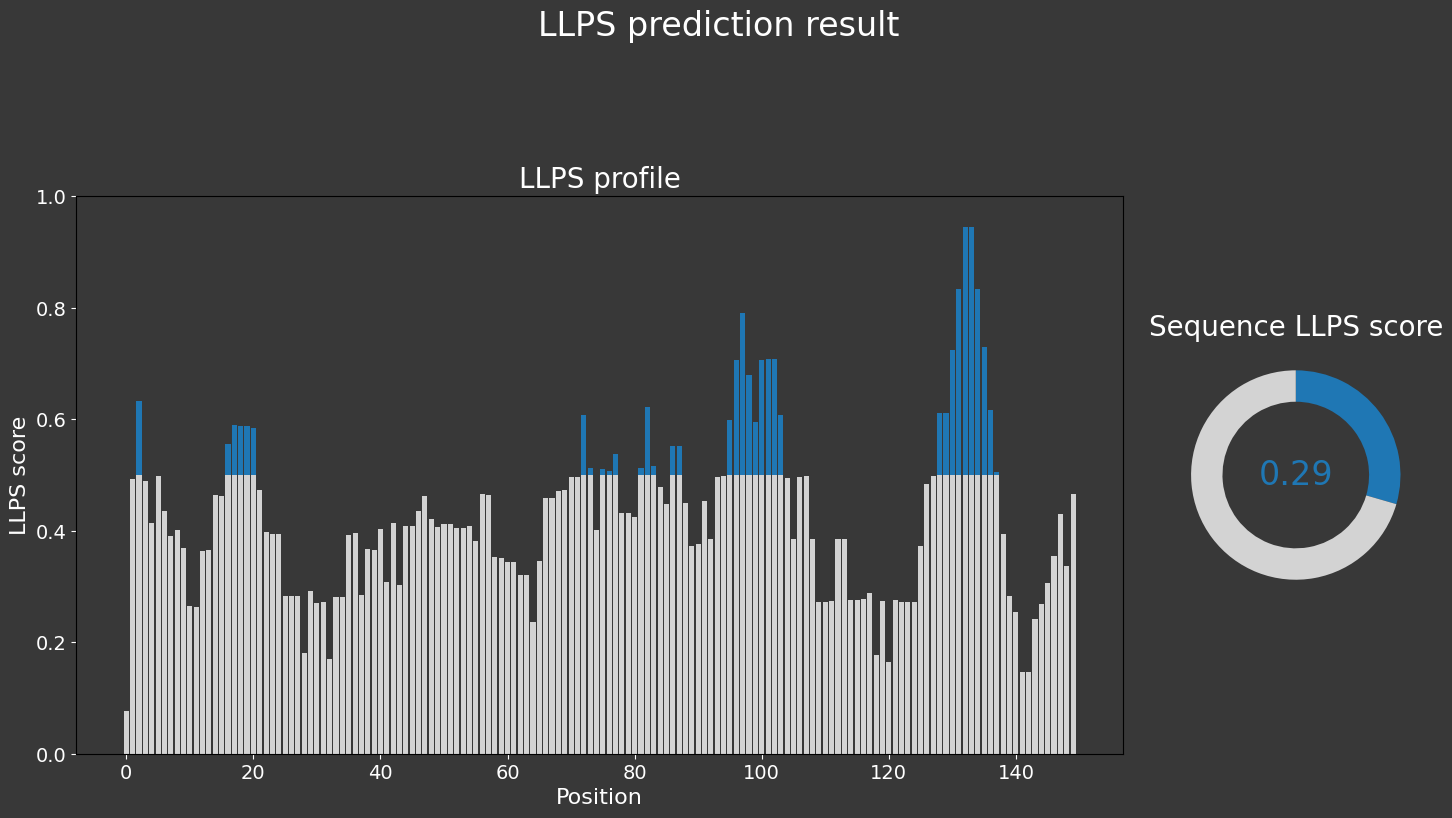

In [5]:
#@title plot
import matplotlib.pyplot as plt
import pandas as pd

if w:
    files = "/content/Phaseek/Results/{dir}/{id}/scores.csv".format(dir = Directory,id = ID)
    scores = pd.read_csv(files)["scores"].values.tolist()
    Sequence = "".join(pd.read_csv(files)["seq"].values.tolist())
    threshold = 0.5
    below_threshold = [min(k, threshold) for k in scores]
    above_threshold = [max(0, k - threshold) for k in scores]
    x_indices = list(range(len(scores)))

    metric_value = score
    main_color = "#1f77b4"
    background_color = "#383838"
    remaining_color = "#d3d3d3"

    fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={'width_ratios': [4, 1]}, facecolor=background_color)

    fig.suptitle("LLPS prediction result", fontsize=24, color="white", y=1.05)
    ax1 = axes[0]
    ax1.bar(x_indices, below_threshold, color=remaining_color, label="Below Threshold")
    ax1.bar(x_indices, above_threshold, bottom=below_threshold, color=main_color, label="Above Threshold")
    ax1.set_ylim(0, 1)

    ax1.set_title("LLPS profile", color="white", fontsize=20)
    ax1.set_xlabel("Position", color="white", fontsize=16)
    ax1.set_ylabel("LLPS score", color="white", fontsize=16)
    ax1.tick_params(colors="white", labelsize=14)
    ax1.set_facecolor(background_color)
    ax2 = axes[1]
    ax2.pie(
        [metric_value, 1 - metric_value],
        colors=[main_color, remaining_color],
        startangle=90,
        counterclock=False,
        wedgeprops={'width': 0.3})

    ax2.text(0, 0, f'{metric_value:.2f}', ha='center', va='center', fontsize=24, color=main_color)
    ax2.set_aspect('equal')
    ax2.set_facecolor(background_color)
    ax2.axis('off')
    ax2.set_title("Sequence LLPS score", fontsize=20, color="white")

    plt.tight_layout(pad=3.0)
    plt.savefig("/content/Phaseek/Results/{dir}/{id}/LLPS_profile{iD}.svg".format(dir = Directory,id = ID,iD = ID), format='svg', bbox_inches='tight', facecolor=background_color)
    plt.show()


In [6]:
#@title Downloading the results

import shutil
import os
from google.colab import files

# Define the directory to be zipped
directory_to_zip = '/content/Phaseek/Results'

# Output zip file name
zip_file_name = '/content/Phaseek_analysis_results.zip'

# Create the ZIP file
shutil.make_archive(base_name=zip_file_name.replace('.zip', ''),
                    format='zip',
                    root_dir=directory_to_zip)

# Download the ZIP file
files.download(zip_file_name)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Generating Phase-Separating Peptides with **Phaseek**  



You can choose between two optimization strategies:

- **SeqProp (Gradient-Based)** – continuous, gradient-based optimization in sequence space  
- **AutoRegressive (Greedy/Stochastic)** – stepwise, language-model–style construction of sequences  

---

## 1️⃣ Comparison of Design Methods

| Feature | **SeqProp (Gradient-Based)** | **AutoRegressive (Greedy/Stochastic)** |
| :--- | :--- | :--- |
| **Search Space** | **Continuous** (log-probability profile $\boldsymbol{\theta}$ over amino acids) | **Discrete** (explicit amino acid sequence) |
| **Core Mechanism** | Gradient-based optimization (backprop through the Transformer) | Stepwise choice based on predicted score at each position |
| **Benefits** | • **Global-ish search:** explores a smooth, continuous landscape, can escape some discrete traps.  <br>• **Score-focused:** directly maximizes the model’s LLPS score over the whole sequence. | • **Fast:** one forward pass per position, very efficient. <br>• **Simple:** always produces a valid sequence quickly. |
| **Drawbacks** | • **Hyperparameter-sensitive:** needs reasonable settings for LR, temperature, and entropy weight. <br>• **Heavier compute:** hundreds of optimization steps per sequence. | • **Local myopia:** early residue choices strongly constrain later positions. <br>• More prone to local optima in **discrete** sequence space. |

---

## 2️⃣ Controllable Parameters

These sliders/fields control how the model searches sequence space.  
Choose **SeqProp** or **AutoRegressive** first, then tune the corresponding parameters.

---

### 📈 SeqProp Parameters (Gradient-Based Optimization)

SeqProp optimizes a **continuous amino acid profile** $\boldsymbol{\theta}$ over the sequence, then decodes it into a discrete sequence.

| Parameter | Explanation | Key Effect on Design |
| :--- | :--- | :--- |
| **GRADIENT\_STEPS** | Number of optimization iterations. | Higher → deeper optimization and typically higher scores, but slower. Lower → faster, but may stop before convergence. |
| **LEARNING\_RATE** | Step size for gradient updates on $\boldsymbol{\theta}$. | Too high → unstable or oscillating scores; too low → very slow improvement. Tuning this can strongly affect performance. |
| **ENTROPY\_WEIGHT** | $\lambda$ in:  $$\text{Loss} = - \text{Score} + \lambda \cdot \text{Entropy}$$ | Higher $\lambda$ → penalizes very “peaky” profiles less aggressively, keeping distributions smoother for longer. Lower $\lambda$ → encourages quicker collapse to one-hot–like choices. |
| **TEMP\_START / TEMP\_END** | Initial and final temperature used inside Softmax on $\boldsymbol{\theta}$. | High **TEMP\_START** → broad exploration at the beginning. Low **TEMP\_END** → sharp, confident amino acid choices at the end. This annealing schedule balances exploration vs. exploitation. |
| **ENABLE\_REFINEMENT** | If enabled, runs a discrete, single-residue local search after decoding the SeqProp profile. | Usually improves the final score by fixing small suboptimal residues; costs extra time for long sequences. |

---

### 🔨 AutoRegressive Parameters (Greedy/Stochastic Design)

The AutoRegressive method builds the sequence **left-to-right**, choosing one residue at a time using the model’s scores.

| Parameter | Explanation | Key Effect on Design |
| :--- | :--- | :--- |
| **K\_CHOICES** | At each position, the next residue is sampled from the **top $K$ scoring amino acids**. | $K = 1$ → purely greedy (more deterministic, often higher score, less diversity).  <br>$K > 1$ → introduces randomness within the top options, improving diversity but sometimes slightly reducing score. |
| **START\_SEQUENCE** | A prefix (e.g. `"M"`, `"MM"`, `"MGG"`). This is fixed at the N-terminus. | Biases generation toward sequences compatible with your chosen N-terminal motif. Useful when you want to preserve tags, signal peptides, or motifs derived from a real protein. |

---

### When to Use Which Method?

- Choose **SeqProp (Gradient-Based)** if you:
  - Want **fewer, more optimized** sequences.
  - Care about squeezing out the **highest possible LLPS scores**.
  - Don’t mind a heavier computation per design.

- Choose **AutoRegressive (Greedy/Stochastic)** if you:
  - Want **many diverse candidates quickly**.
  - Prefer an LM-style, intuitive “grow the sequence” behaviour.
  - Are exploring ideas and not yet chasing a single optimum.

Once you’ve chosen a method and tuned the parameters, run the cell to generate sequences and inspect their predicted LLPS scores.



In [12]:
#@title **Setup and Interactive Transformer-Guided Sequence Design**
#@markdown This cell loads the model and sets up the interactive controls for design.

# --- 1. SETUP: Imports and Global Variables ---

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm, trange
import time

# --- External Module Placeholder/Import ---
try:
    from classifier_fgs import transformer
except ImportError:
    print("FATAL ERROR: 'classifier_fgs' module not found. Using Dummy Model.")
    # Dummy Model for demonstration purposes
    class DummyWrapper:
        def __init__(self, mode):
            d_emb = 128
            vocab_size = 30
            self._classifier = type('DummyClassifier', (), {
                'eval': lambda: None, 'parameters': lambda: [], 'to': lambda x: None,
                'transformer': type('DummyTransformer', (), {
                    'wte': type('DummyWTE', (), {'weight': torch.randn(vocab_size, d_emb)}),
                    'wpe': lambda x: torch.zeros(x.shape[0], x.shape[1], d_emb),
                    'drop': lambda x: x, 'h': [], 'ln_f': lambda x: x
                }),
                'ny': lambda x: x, 'classifier_head': lambda x: torch.randn(1, 2)
            })()
            self.vocab_dict = {a: i for i, a in enumerate("ACDEFGHIKLMNPQRSTVWY")}
        def predict_proba(self, seqs):
            scores = []
            for seq in seqs:
                charge_content = sum(seq.count(c) for c in 'RDEK') / len(seq) if len(seq) > 0 else 0
                score = 0.5 + 0.5 * np.tanh(charge_content * 5 - 2.5) # Mock score
                scores.append([score, 1.0 - score])
            return np.array(scores)

    def transformer(mode): return DummyWrapper(mode)

# Define the global device/AA list
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_cuda_amp = (device.type == "cuda") and torch.cuda.is_available()
AA = "ACDEFGHIKLMNPQRSTVWY"
K = len(AA)

# Initialize the model globally
try:
    model = transformer("c")
except Exception as e:
    print(f"Global model initialization failed: {e}")
    model = None


# --- 2. CORE FUNCTIONS (Copied from generator.py) ---

def get_classifier_and_W_AA(mode: str = "c"):
    wrapper = transformer(mode)
    clf = wrapper._classifier
    clf.eval()
    for p in clf.parameters():
        p.requires_grad = False
    vocab = wrapper.vocab_dict
    aa_token_ids = [vocab[a] for a in AA if a in vocab]
    W_full = clf.transformer.wte.weight.detach()
    W_AA = W_full[aa_token_ids, :].to(device)
    clf.to(device)
    return wrapper, clf, W_AA

def scorerr(seq):
    if model is None: return 0.0
    def edit(i):
        valid_chars = set("ACDEFGHIKLMNPQRSTVWY")
        return "".join(c.upper() for c in i if c.upper() in valid_chars)
    Sequence = edit(seq)
    if not Sequence: return 0.0
    u = model.predict_proba([Sequence])
    if u.ndim == 2: u = u[0, 0]
    elif u.ndim == 1: u = u[0]
    return float(u)

def greedy_refine(seq, wrapper, max_iters=200):
    best_seq = list(seq)
    best_score = scorerr("".join(best_seq))
    for _ in range(max_iters):
        improved = False
        for pos in range(len(best_seq)):
            current_res = best_seq[pos]
            for a in AA:
                if a == current_res: continue
                cand = best_seq[:]
                cand[pos] = a
                s = scorerr("".join(cand))
                if s > best_score:
                    best_score = s
                    best_seq = cand
                    improved = True
                    break
            if improved: break
        if not improved: break
    return "".join(best_seq), best_score

# --- SeqProp Function (Truncated for Colab length) ---
def run_seqprop(**kwargs):
    # This function uses the gradient-based method (copied from above)
    length = kwargs.get('length', 120)
    steps = kwargs.get('steps', 300)
    lr = kwargs.get('lr', 0.02)
    entropy_weight = kwargs.get('entropy_weight', 0.05)
    mode = kwargs.get('mode', 'c')
    seed = kwargs.get('seed', 0)
    log_every = kwargs.get('log_every', 20)
    refine = kwargs.get('refine', True)
    temp_start = kwargs.get('temp_start', 2.0)
    temp_end = kwargs.get('temp_end', 0.1)

    torch.manual_seed(seed)
    np.random.seed(seed)

    wrapper, clf, W_AA = get_classifier_and_W_AA(mode=mode)
    L = length
    theta = torch.randn(L, K, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([theta], lr=lr)
    scaler = torch.amp.GradScaler('cuda', enabled=use_cuda_amp)
    best_theta = None
    best_score_val = -1.0

    print(f"--- Starting SeqProp (L={L}, Steps={steps}) ---")

    for step in range(steps):
        current_temp = temp_start + (temp_end - temp_start) * (step / steps)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_cuda_amp):
            P_soft = F.softmax(theta / current_temp, dim=-1)
            E = P_soft @ W_AA
            # Simplified Forward Pass Block (assuming internal CLF structure remains constant)
            x = E.unsqueeze(0); T = x.size(1)
            pos = torch.arange(0, T, dtype=torch.long, device=device).unsqueeze(0)
            x = clf.transformer.drop(x + clf.transformer.wpe(pos))
            for block in clf.transformer.h: x = block(x)
            logits = clf.ny(clf.classifier_head(clf.transformer.ln_f(x))).mean(1)
            score = torch.sigmoid(logits)[:, 0]

            P_real = F.softmax(theta, dim=-1)
            entropy = -(P_real * torch.clamp(P_real, min=1e-9).log()).sum(-1).mean()
            loss = -score.mean() + (entropy_weight * entropy)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        score_val = float(score.item())
        if score_val > best_score_val and step > (steps // 2):
            best_score_val = score_val
            best_theta = theta.detach().clone()
        if (step + 1) % max(1, log_every) == 0 or step == 0:
            print(f"Step {step+1}/{steps} | Temp: {current_temp:.2f} | Score (soft): {score_val:.4f} | Entropy: {float(entropy.item()):.4f}")

    if best_theta is None: best_theta = theta.detach()
    with torch.no_grad():
        P_final = F.softmax(best_theta, dim=-1).cpu().numpy()
        idxs = np.argmax(P_final, axis=1)
        seq_seqprop = "".join(AA[i] for i in idxs)
        score_seqprop = scorerr(seq_seqprop)

    print(f"Predicted LLPS score (wrapper) before refinement: {score_seqprop:.6f}")
    if refine:
        refined_seq, refined_score = greedy_refine(seq_seqprop, wrapper, max_iters=200)
        final_seq, final_score = refined_seq, refined_score
    else:
        final_seq, final_score = seq_seqprop, score_seqprop

    return final_seq, final_score


# --- AutoRegressive Function ---
def run_autoregressive_design(**kwargs):
    global model
    length = kwargs.get('length', 120)
    k_choices = kwargs.get('k_choices', 3)
    start_seq = kwargs.get('start_seq', 'M')
    mode = kwargs.get('mode', 'c')
    seed = kwargs.get('seed', 0)

    np.random.seed(seed)

    if model is None:
         # Need to re-initialize model here if it failed globally
         # Removed redundant 'global model' as it's already declared at the function level
         model = transformer(mode)

    CChars = AA
    p11 = list(start_seq)
    while len(p11) < 3 and len(p11) < length:
         p11.append(np.random.choice(list(CChars)))

    print(f"--- Starting AutoRegressive Design (L={length}, k={k_choices}) ---")

    pbar = tqdm(range(len(p11), length), desc="Generating Sequence", leave=False)
    for _ in pbar:
        current_seqs = ["".join(p11) + i for i in CChars]
        SSC = model.predict_proba(current_seqs).ravel().tolist()
        OO = {i: SSC[CChars.index(i)] for i in CChars}

        top_k = sorted(OO, key=lambda x: -OO[x])[:k_choices]
        next_res = np.random.choice(top_k)
        p11.append(next_res)

        current_score = OO[next_res]
        pbar.set_postfix(Score=f"{current_score:.4f}", Res=next_res)

    final_seq = "".join(p11[:length])
    final_score = scorerr(final_seq)

    print(f"\nAutoRegressive Final Score: {final_score:.6f}")

    return final_seq, final_score


# --- 3. INTERACTIVE PARAMETER CONTROL CELL ---

#@markdown # Sequence Design Tool
#@markdown Choose your design method and set parameters below.
#@markdown ---
#@markdown ## Design Settings
DESIGN_METHOD = "AutoRegressive (Greedy/Stochastic)" #@param ["SeqProp (Gradient-Based)", "AutoRegressive (Greedy/Stochastic)"]
DESIGN_MODE = "c" #@param ["a", "b", "c", "d", "e", "f", "g", "h"]
SEQUENCE_LENGTH = 120 #@param {type:"slider", min:20, max:512, step:10}
NUMBER_OF_SEQUENCES = 3 #@param {type:"slider", min:1, max:10, step:1}
RANDOM_SEED = 42 #@param {type:"number"}

#@markdown ---
#@markdown ## SeqProp Parameters (Only used if SeqProp is selected)
GRADIENT_STEPS = 500 #@param {type:"slider", min:100, max:1000, step:100}
LEARNING_RATE = 0.1 #@param {type:"number"}
ENTROPY_WEIGHT = 0.1 #@param {type:"number"}
TEMP_START = 2.0 #@param {type:"number"}
TEMP_END = 0.1 #@param {type:"number"}
ENABLE_REFINEMENT = False #@param {type:"boolean"}
LOG_EVERY_N_STEPS = 50 #@param {type:"number"}

#@markdown ---
#@markdown ## AutoRegressive Parameters (Only used if AutoRegressive is selected)
K_CHOICES = 3 #@param {type:"slider", min:1, max:10, step:1}
START_SEQUENCE = "M" #@param {type:"string"}


# --- EXECUTION LOGIC ---
all_results = []
start_time = time.time()
method_key = DESIGN_METHOD.split(" ")[0] # Extracts "SeqProp" or "AutoRegressive"

print(f"\n--- Starting {DESIGN_METHOD} Design for {NUMBER_OF_SEQUENCES} sequence(s) ---")
print("-" * 60)

for i in range(NUMBER_OF_SEQUENCES):
    current_seed = RANDOM_SEED + i
    print(f"\n>>>> SEQUENCE {i+1}/{NUMBER_OF_SEQUENCES} (Seed: {current_seed}) <<<<")

    if method_key == "SeqProp":
        final_seq, final_score = run_seqprop(
            length=SEQUENCE_LENGTH, steps=GRADIENT_STEPS, lr=LEARNING_RATE, entropy_weight=ENTROPY_WEIGHT,
            mode=DESIGN_MODE, seed=current_seed, log_every=LOG_EVERY_N_STEPS, refine=ENABLE_REFINEMENT,
            temp_start=TEMP_START, temp_end=TEMP_END
        )
    elif method_key == "AutoRegressive":
        final_seq, final_score = run_autoregressive_design(
            length=SEQUENCE_LENGTH, k_choices=K_CHOICES, start_seq=START_SEQUENCE,
            mode=DESIGN_MODE, seed=current_seed
        )
    else:
        raise ValueError(f"Unknown design method: {DESIGN_METHOD}")

    all_results.append({
        'ID': f'Design_{i+1}_{method_key}',
        'Sequence': final_seq,
        'Score': final_score,
        'Method': method_key,
        'Seed': current_seed
    })

end_time = time.time()
print("\n" + "="*60)
print(f"DESIGN COMPLETE in {end_time - start_time:.2f} seconds")
print("FINAL SEQUENCES SUMMARY")
print("="*60)

for res in all_results:
    print(f"ID: {res['ID']} | Score: {res['Score']:.6f} | L: {len(res['Sequence'])} | Seq: {res['Sequence']}...")


--- Starting AutoRegressive (Greedy/Stochastic) Design for 3 sequence(s) ---
------------------------------------------------------------

>>>> SEQUENCE 1/3 (Seed: 42) <<<<
--- Starting AutoRegressive Design (L=120, k=3) ---



AutoRegressive Final Score: 0.948802

>>>> SEQUENCE 2/3 (Seed: 43) <<<<
--- Starting AutoRegressive Design (L=120, k=3) ---



AutoRegressive Final Score: 0.949975

>>>> SEQUENCE 3/3 (Seed: 44) <<<<
--- Starting AutoRegressive Design (L=120, k=3) ---



AutoRegressive Final Score: 0.951444

DESIGN COMPLETE in 25.59 seconds
FINAL SEQUENCES SUMMARY
ID: Design_1_AutoRegressive | Score: 0.948802 | L: 120 | Seq: MHYCAACCMTKAKVAGQCGRAATIRVVVAMMMVAAIQQENVMAHYMAYMVTYAAVVAKGVHSGGKTQHHGKVGKKRQKKKYKKVKEMNHHNCAVVRNNRHNKNEHYPNHNEMFYEYENQM...
ID: Design_2_AutoRegressive | Score: 0.949975 | L: 120 | Seq: MFATGCCWGTGCKTMAQRCCIACACTCWCIVICIIAVCCMMCVHMHAAKNHMFAGFHFKFMASNHVQHFHYNQNFVHYHFKAFNFNKGHFFFFNHAYFDVNKNFYYAAYWVAMAVYMMAV...
ID: Design_3_AutoRegressive | Score: 0.951444 | L: 120 | Seq: MEVGGGEEQQPGQEPGPGEEGPEPEPPEGGEGKGQKEENANDLNFVFANDYFRVALHHYRLNYFHRVFFYNLNEGKGGGEEDPPAALFALDDFEWGPDALKEAMKAKFLHGEFFAEEKEG...
